# Oklahoma Non-Emergency Medical Transport Analysis
## January – February 2025

**Presenter:** Angie "Gigi" Campuzano  
**Data Source:** OKRC Ride Request Data  
**Dataset Size:** 20,831 rides across Jan-Feb 2025  

### Research Questions:
1. Which day of the week has the most ride requests?
2. What time of day peaks for ride requests?
3. Which Oklahoma regions have the highest demand?

In [24]:
#--- Imports ---
# pandas helps us work with tables of data
# matplotlib helps us make charts

import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# --- Load the Data ---
rides = pd.read_csv("FullDataWithDrivetimeJanFeb2025.csv")
regions = pd.read_csv("OkrcRegionLookup.csv")

# peek at data
print(rides.shape)
print(rides.head())

(20851, 13)
   Unnamed: 0 datestringRequestedPickup  \
0           0       2026-01-27 13:22:39   
1           1       2026-02-17 06:30:00   
2           2       2026-02-19 13:27:38   
3           3       2026-02-19 17:37:20   
4           4       2026-02-10 07:45:00   

                                       pickupAddress  \
0  2625 General Pershing Blvd, Oklahoma City, OK ...   
1           4564 W 141st St S, Kiefer, OK 74041, USA   
2        1420 N Harrison Ave, Shawnee, OK 74801, USA   
3           107 N Main St, Kingfisher, OK 73750, USA   
4          1401 E Chickasaw Ave, McAlester, OK 74501   

                                  destinationAddress Requested_Transport_Date  \
0               900 E Main St, Norman, OK 73071, USA      2026-01-27 13:22:39   
1            2727 E Admiral Pl, Tulsa, OK 74110, USA      2026-02-17 06:30:00   
2        1002 W 7th St apt 5, Shawnee, OK 74801, USA      2026-02-19 13:27:38   
3      2250 N Airport Rd, Weatherford, OK 73096, USA      2026-02-19

In [3]:
# --- Inspect the Data ---
# Check for missing values and data types
# This is called "data wrangling" — a rubric requirement!

print(rides.isnull().sum())
print()
print(rides.dtypes)

Unnamed: 0                         0
datestringRequestedPickup          0
pickupAddress                     14
destinationAddress                14
Requested_Transport_Date           1
Requested_Transport_Date_Time      1
departure_unix                     1
pick_up_lat                      153
pick_up_lng                      153
drop_off_lat                     153
drop_off_lng                     153
drive_time_min                   153
drive_time_in_traffic_min        153
dtype: int64

Unnamed: 0                         int64
datestringRequestedPickup            str
pickupAddress                        str
destinationAddress                   str
Requested_Transport_Date             str
Requested_Transport_Date_Time        str
departure_unix                   float64
pick_up_lat                      float64
pick_up_lng                      float64
drop_off_lat                     float64
drop_off_lng                     float64
drive_time_min                   float64
drive_time_in

In [4]:
# --- Clean the Data ---
# Drop rows where pickupAddress is missing — we can't use them

rides = rides.dropna(subset=['pickupAddress', 'destinationAddress'])

# Convert date column from text to an actual datetime
rides['Requested_Transport_Date_Time'] = pd.to_datetime(rides['Requested_Transport_Date_Time'])

#Confirm it worked
print(rides.shape)
print(rides['Requested_Transport_Date_Time'].dtype)

(20831, 13)
datetime64[us]


In [5]:
# --- Extract Zip Codes and Date Parts ---
# .str.extract() finds a pattern inside a text column
# '\d{5}' means "find exactly 5 digits in a row" — that's a zip code

rides['pickup_zip'] = rides['pickupAddress'].str.extract(r'(\d{5})')
rides['dropoff_zip'] = rides['destinationAddress'].str.extract(r'(\d{5})')

# Extract weekday and hour from the datetime column
rides['weekday'] = rides['Requested_Transport_Date_Time'].dt.day_name()
rides['hour'] = rides['Requested_Transport_Date_Time'].dt.hour

# Check it worked
print(rides[['pickupAddress', 'pickup_zip', 'weekday', 'hour']].head())

                                       pickupAddress pickup_zip   weekday  \
0  2625 General Pershing Blvd, Oklahoma City, OK ...      73107   Tuesday   
1           4564 W 141st St S, Kiefer, OK 74041, USA      74041   Tuesday   
2        1420 N Harrison Ave, Shawnee, OK 74801, USA      74801  Thursday   
3           107 N Main St, Kingfisher, OK 73750, USA      73750  Thursday   
4          1401 E Chickasaw Ave, McAlester, OK 74501      74501   Tuesday   

   hour  
0  13.0  
1   6.0  
2  13.0  
3  17.0  
4   7.0  


In [6]:
#Let's see ALL column names in both tables
print("RIDES columns:")
print(rides.columns.tolist())
print()
print("REGION columns:")
print(regions.columns.tolist())

RIDES columns:
['Unnamed: 0', 'datestringRequestedPickup', 'pickupAddress', 'destinationAddress', 'Requested_Transport_Date', 'Requested_Transport_Date_Time', 'departure_unix', 'pick_up_lat', 'pick_up_lng', 'drop_off_lat', 'drop_off_lng', 'drive_time_min', 'drive_time_in_traffic_min', 'pickup_zip', 'dropoff_zip', 'weekday', 'hour']

REGION columns:
['ZCTA', 'cityName', 'countyCodes', 'countyNames', 'countyWeights', 'density', 'imprecise', 'latitude', 'longitude', 'military', 'okrcRegion', 'population', 'primaryCountyCode', 'primaryCountyName', 'stateCode', 'stateCodeAndOkrcRegion', 'stateName', 'timeZone', 'zctaParent', 'zipcode', 'objectId', 'ownerId', 'created', 'updated']


In [7]:
# --- Merge with Region Lookup ---
# Keep only the columns we need from the regions table
# drop_duplicates() makes sure we don't have repeat zip codes


region_slim = regions[['zipcode', 'okrcRegion']].drop_duplicates()

region_slim['zipcode'] = region_slim['zipcode'].astype(str)

rides = rides.merge(region_slim, left_on='pickup_zip', right_on='zipcode', how='left')

print(rides[['pickup_zip', 'okrcRegion']].head(10))
print()
print(rides['okrcRegion'].value_counts())


  pickup_zip   okrcRegion
0      73107    OKC metro
1      74041    Northeast
2      74801    Southeast
3      73750    Northwest
4      74501    Southeast
5      74114  Tulsa metro
6      74112  Tulsa metro
7      74467    Northeast
8      74114  Tulsa metro
9      73071    OKC metro

okrcRegion
OKC metro      6802
Tulsa metro    6725
Southeast      2737
Southwest      1654
Northeast      1598
Undefined       477
Northwest       214
Name: count, dtype: int64


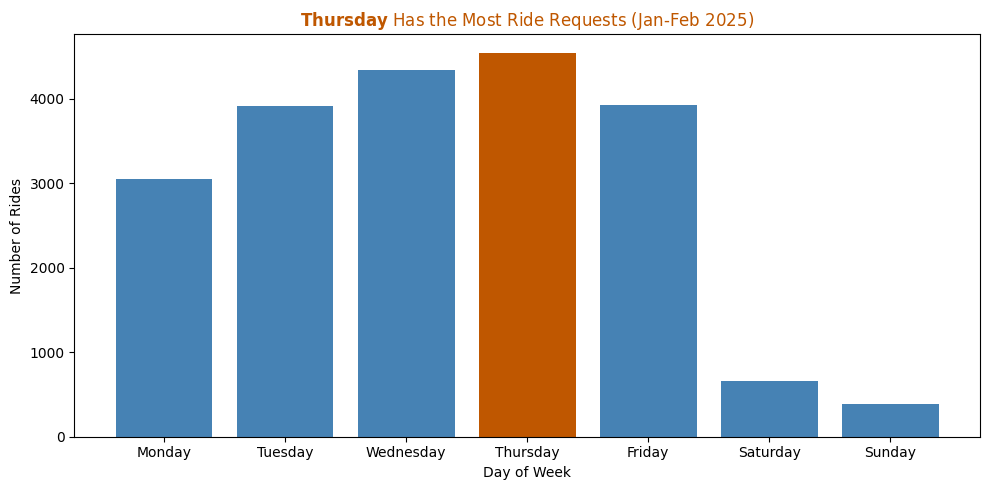

In [8]:
# --- Chart 1: Rides by Weekday ---
# Drop any rows where weekday is missing
rides_clean = rides.dropna(subset=['weekday'])

# Count rides per weekday
weekday_counts = rides_clean.groupby('weekday').size().reset_index(name='ride_count')

# Sort by correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = weekday_counts.set_index('weekday').reindex(day_order).reset_index()

# Highlighting Thursday only
colors = ['steelblue', 'steelblue', 'steelblue', '#BF5700', 'steelblue', 'steelblue', 'steelblue',]

# Draw the chart
plt.figure(figsize=(10, 5))
plt.bar(weekday_counts['weekday'], weekday_counts['ride_count'], color=colors)
plt.title('$\\bf{Thursday}$ Has the Most Ride Requests (Jan-Feb 2025)', color='#BF5700')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

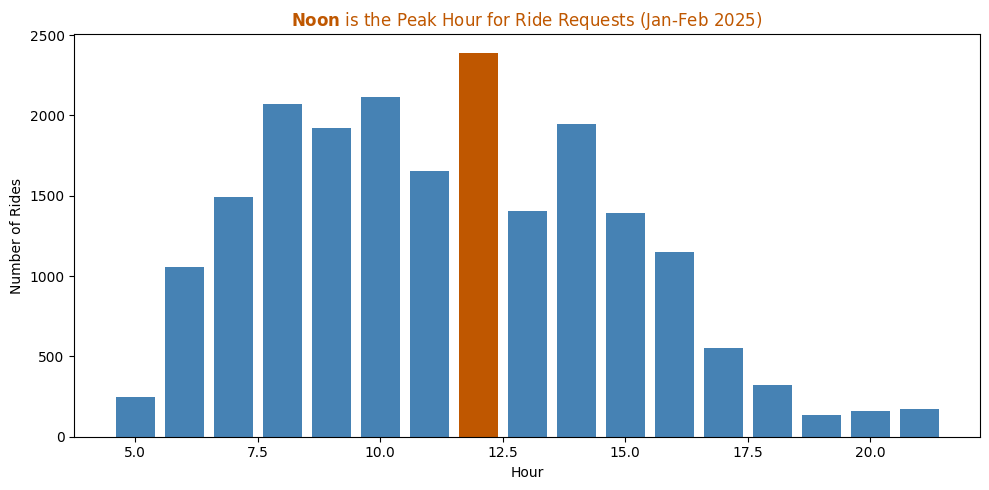

In [9]:
# --- Chart 2: Rides by Hour
rides_clean = rides.dropna(subset=['hour'])

# GroupBy
hour_counts = rides_clean.groupby('hour').size().reset_index(name='ride_count')

# Filter to just show 5am to 9pm
hour_counts = hour_counts[hour_counts['hour'].between(5,21)]

# Highlighting insight
colors= ['steelblue', 'steelblue', 'steelblue', 'steelblue', 
         'steelblue', 'steelblue', 'steelblue', '#BF5700',
         'steelblue', 'steelblue', 'steelblue', 'steelblue', 
         'steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue',]

plt.figure(figsize=(10, 5))
plt.bar(hour_counts['hour'], hour_counts['ride_count'], color=colors)
plt.title('$\\bf{Noon}$ is the Peak Hour for Ride Requests (Jan-Feb 2025)', color='#BF5700')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()
        

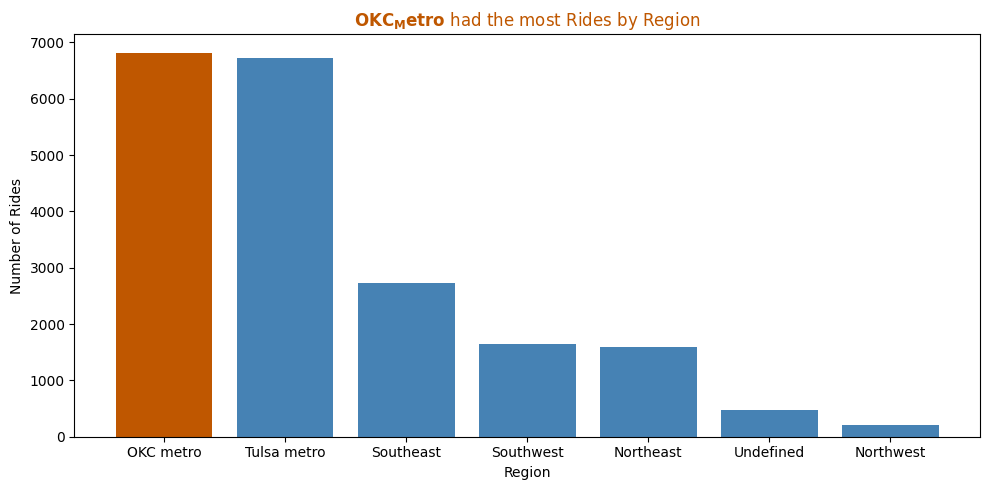

In [10]:
#--- CHART 3: Rides by Region Chart --- 
rides_clean = rides.dropna(subset=['okrcRegion'])
region_counts = rides_clean.groupby('okrcRegion').size().reset_index(name='ride_count')
region_counts = region_counts.sort_values('ride_count', ascending=False)

colors=['#BF5700', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue',]

plt.figure(figsize=(10, 5))
plt.bar(region_counts['okrcRegion'], region_counts['ride_count'], color=colors)
plt.title('$\\bf{OKC_Metro}$ had the most Rides by Region', color='#BF5700')
plt.xlabel('Region')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

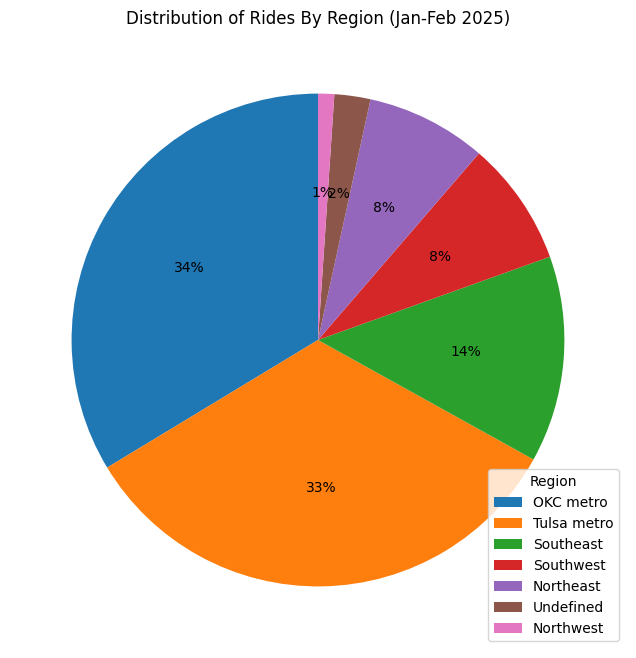

In [11]:
# --- Chart 4: zrides by Region (PIE CHART) ---
plt.figure(figsize=(8, 8))
plt.pie(region_counts['ride_count'],
        labels=None, 
        autopct='%1.0f%%',
        startangle=90)
plt.title('Distribution of Rides By Region (Jan-Feb 2025)')
plt.legend(region_counts['okrcRegion'],
           title='Region',
           loc='lower right')
plt.show()

## Conclusion

Analysis of 20,831 non-emergency medical transport rides in Oklahoma from January to February 2025 reveals three key patterns:  

**Day of the Week:** Thursday is the busiest day for ride requests, suggesting many patients schedule medical appointments mid-week. Weekend rides drop dramatically, with Sunday being the slowest day.  

**Time of Day:** Noon is the peak hour for ride requests, with a secondary morning peak around 7-8am. This pattern is consistent with typical medical appointment scheduling during business hours.  

**Regional Distribution:** The OKC Metro region accounts for the most ride requests, followed closely by Tulsa Metro. Together these two urban regions represent the majority of all NEMT demand in Oklahoma, while rural regions like Northwest Oklahoma show significantly fewer requests.  

**Data Note:** A small number of rides (477) were classified as "Undefined" region, likely due to zip codes not matching the lookup table. This represents approximately 2% of total rides and does not significantly impact analysis.

In [12]:
!pip install folium



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# --- Load Oklahoma County Shapefile ---
# We're loading county boundary shapes directly from the Census Bureau
# gpd.read_file() can load a zipped shapefile directly from a URL

import geopandas as gpd
import folium

url = 'https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_500k.zip'

# Loading all US counties
counties = gpd.read_file(url)

# Filter to just Oklahoma - state code for Oklahoma is '40'
oklahoma = counties[counties['STATEFP'] == '40']

# Check it loaded correctly
print(oklahoma.shape)
print(oklahoma.columns.tolist())
print(oklahoma.head())
 

(77, 13)
['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']
    STATEFP COUNTYFP  COUNTYNS        AFFGEOID  GEOID        NAME  \
98       40      095  01101832  0500000US40095  40095    Marshall   
99       40      013  01101794  0500000US40013  40013       Bryan   
100      40      023  01101799  0500000US40023  40023     Choctaw   
228      40      027  01101801  0500000US40027  40027   Cleveland   
378      40      147  01101861  0500000US40147  40147  Washington   

              NAMELSAD STUSPS STATE_NAME LSAD       ALAND     AWATER  \
98     Marshall County     OK   Oklahoma   06   962153980  143719930   
99        Bryan County     OK   Oklahoma   06  2342250032  101809038   
100     Choctaw County     OK   Oklahoma   06  1995281898   75475686   
228   Cleveland County     OK   Oklahoma   06  1395713124   49261324   
378  Washington County     OK   Oklahoma   06  1076201531   22871165   

   

In [14]:
# --- Folium Choropleth Map ---
# Step 1: Add okrcRegion to each Oklahoma county
# We need to connect county names to regions
# First let's see what county names look like in our shapefile
print(oklahoma['NAME'].tolist())


['Marshall', 'Bryan', 'Choctaw', 'Cleveland', 'Washington', 'Kiowa', 'Osage', 'Kingfisher', 'Jackson', 'Le Flore', 'Sequoyah', 'Pottawatomie', 'McClain', 'Wagoner', 'Seminole', 'McCurtain', 'Pawnee', 'Tillman', 'Muskogee', 'Jefferson', 'Tulsa', 'Mayes', 'Cherokee', 'Craig', 'Caddo', 'Nowata', 'Haskell', 'Blaine', 'McIntosh', 'Cotton', 'Texas', 'Love', 'Ellis', 'Alfalfa', 'Beaver', 'Murray', 'Pontotoc', 'Oklahoma', 'Ottawa', 'Woods', 'Creek', 'Beckham', 'Logan', 'Rogers', 'Canadian', 'Comanche', 'Grady', 'Garfield', 'Roger Mills', 'Cimarron', 'Pittsburg', 'Stephens', 'Washita', 'Latimer', 'Hughes', 'Major', 'Greer', 'Harmon', 'Payne', 'Dewey', 'Noble', 'Atoka', 'Okfuskee', 'Custer', 'Coal', 'Okmulgee', 'Johnston', 'Adair', 'Delaware', 'Kay', 'Pushmataha', 'Grant', 'Lincoln', 'Garvin', 'Harper', 'Carter', 'Woodward']


In [15]:
# filter regions to just Oklahoma
oklahoma_regions = regions[regions['stateCode'] == 'OK']

print(oklahoma_regions.shape)
print(oklahoma_regions[['zipcode','okrcRegion', 'countyNames']].head(20))

(649, 24)
       zipcode okrcRegion             countyNames
24626    73002  Southwest                   Grady
24627    73003  OKC metro                Oklahoma
24628    73004  Southwest                   Grady
24629    73005  Southwest                   Caddo
24630    73006  Southwest         Caddo, Comanche
24631    73007  OKC metro         Oklahoma, Logan
24632    73008  OKC metro                Oklahoma
24633    73009  Southwest                   Caddo
24634    73010  Southwest          McClain, Grady
24635    73011  Southwest                   Grady
24636    73012  OKC metro                Oklahoma
24637    73013  OKC metro                Oklahoma
24638    73014  Southwest                Canadian
24639    73015  Southwest   Caddo, Kiowa, Washita
24640    73016  Northwest       Kingfisher, Logan
24641    73017  Southwest  Caddo, Grady, Comanche
24642    73018  Southwest                   Grady
24643    73019  OKC metro               Cleveland
24645    73020  OKC metro     Oklahoma, 

In [16]:
# --- Step 2: Get one region per county (simpler approach) ---
# Split multi-county entries and explode them into separate rows
oklahoma_regions_copy = oklahoma_regions.copy()

# Split county names that have commas into separate rows
oklahoma_regions_copy['countyNames'] = oklahoma_regions_copy['countyNames'].str.split(', ')
oklahoma_regions_exploded = oklahoma_regions_copy.explode('countyNames')

# Now get one region per single county name
county_region = oklahoma_regions_exploded.groupby('countyNames')['okrcRegion'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

county_region.columns = ['NAME', 'okrcRegion']

# Check it
print(county_region.head(20))
print(county_region.shape)

         NAME okrcRegion
0       Adair  Northeast
1     Alfalfa  Northwest
2       Atoka  Southeast
3      Beaver  Northwest
4     Beckham  Southwest
5      Blaine  Northwest
6       Bryan  Southeast
7       Caddo  Southwest
8    Canadian  Southwest
9      Carter  Southeast
10   Cherokee  Northeast
11    Choctaw  Southeast
12   Cimarron  Northwest
13  Cleveland  OKC metro
14       Coal  Southeast
15   Comanche  Southwest
16     Cotton  Southwest
17      Craig  Northeast
18      Creek  Northeast
19     Custer  Northwest
(78, 2)


In [17]:
# --- Step 3: Merge everything together ---
# Merge county shapes with their regions
oklahoma_map = oklahoma.merge(county_region, on='NAME', how='left')

# Merge ride counts onto the map
oklahoma_map = oklahoma_map.merge(region_counts, on='okrcRegion', how='left')

# Check it worked
print(oklahoma_map[['NAME', 'okrcRegion', 'ride_count']].head(10))

         NAME okrcRegion  ride_count
0    Marshall  Southeast        2737
1       Bryan  Southeast        2737
2     Choctaw  Southeast        2737
3   Cleveland  OKC metro        6802
4  Washington  Northeast        1598
5       Kiowa  Southwest        1654
6       Osage  Northeast        1598
7  Kingfisher  Northwest         214
8     Jackson  Southwest        1654
9    Le Flore  Southeast        2737


In [22]:
# --- Step 4: Build the Folium Choropleth Map ---
# Convert our map data to GeoJSON format for Folium
oklahoma_json = oklahoma_map.to_json()

# Create the base map centered on Oklahoma
m = folium.Map(location=[35.5, -97.5], zoom_start=7)

# Add the choropleth layer
folium.Choropleth(
    geo_data=oklahoma_json,
    data=oklahoma_map,
    columns=['NAME', 'ride_count'],
    key_on='feature.properties.NAME',
    fill_color='PuRd',
    fill_opacity=0.7,
    line_weight=0.5,
    legend_name='Total Ride Requests (Jan-Feb 2025)',
    nan_fill_color='lightgray'
).add_to(m)

# Save the map as an HTML file
m.save('oklahoma_rides_map.html')
print("Map saved!")

Map saved!
